# Exercícios — Máquinas de Vetores de Suporte

**Tema:** Aprendizado Supervisionado › Máquinas de Vetores de Suporte

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split

rng = np.random.default_rng(1313)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — Contando vetores de suporte

Gere duas classes bem separadas (pouca sobreposição) e duas classes muito
sobrepostas. Treine uma SVM linear em cada caso e compare o número de
vetores de suporte. Qual você espera que tenha mais, e por quê?

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
n = 100
X_separado = np.vstack([rng.normal([0, 0], 0.5, (n, 2)), rng.normal([5, 5], 0.5, (n, 2))])
X_sobreposto = np.vstack([rng.normal([0, 0], 2.0, (n, 2)), rng.normal([2, 2], 2.0, (n, 2))])
y = np.concatenate([-np.ones(n), np.ones(n)])

for nome, X in [("bem separadas", X_separado), ("muito sobrepostas", X_sobreposto)]:
    modelo = SVC(kernel="linear", C=1.0).fit(X, y)
    print(f"{nome}: {len(modelo.support_vectors_)} vetores de suporte de {len(X)} pontos")

bem separadas: 3 vetores de suporte de 200 pontos
muito sobrepostas: 104 vetores de suporte de 200 pontos


**Resposta:** o caso sobreposto tem muito mais vetores de suporte — quando
as classes se misturam, mais pontos ficam próximos da fronteira (dentro ou
violando a margem), e todos eles se tornam vetores de suporte. Classes bem
separadas produzem margens "limpas" com poucos pontos por perto.

---
## Exercício 2 🟢 — Kernel polinomial na mão, grau 3

Para $\phi(x) = (x_1^3, \sqrt{3}x_1^2x_2, \sqrt{3}x_1x_2^2, x_2^3)$ (a
expansão de grau 3 para 2 features), confirme numericamente que
$\phi(x)^\top\phi(z) = (x^\top z)^3$ para dois vetores de sua escolha.

In [4]:
# --- sua resposta ---

### Gabarito 2

In [5]:
def phi_cubico(v):
    x1, x2 = v
    return np.array([x1**3, np.sqrt(3) * x1**2 * x2, np.sqrt(3) * x1 * x2**2, x2**3])


x = np.array([1.0, 2.0])
z = np.array([-0.5, 1.5])

produto_explicito = np.dot(phi_cubico(x), phi_cubico(z))
produto_kernel = np.dot(x, z) ** 3

print(f"phi(x)·phi(z) explícito : {produto_explicito:.6f}")
print(f"(x·z)^3 via kernel      : {produto_kernel:.6f}")

phi(x)·phi(z) explícito : 15.625000
(x·z)^3 via kernel      : 15.625000


---
## Exercício 3 🟡 — Diagnosticando overfitting por gamma

Para o dataset `make_moons` com ruído, treine SVMs RBF com `gamma` variando
de muito pequeno a muito grande, mantendo C fixo. Plote acurácia de treino
e de validação cruzada. Em que ponto elas começam a divergir?

In [6]:
# --- sua resposta ---

### Gabarito 3

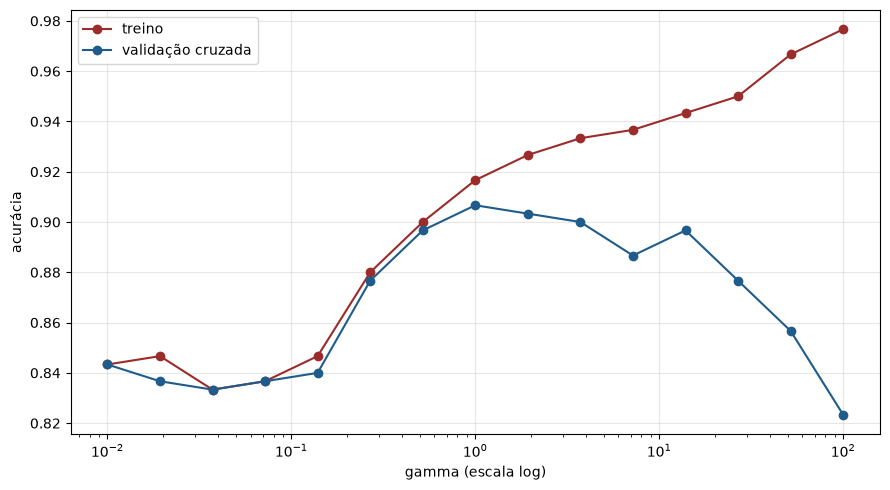

maior gap treino-CV em gamma=100.0000 (gap=0.1533)


In [7]:
X, y = make_moons(n_samples=300, noise=0.3, random_state=1)
X = StandardScaler().fit_transform(X)

valores_gamma = np.logspace(-2, 2, 15)
acc_treino, acc_cv = [], []
for gamma in valores_gamma:
    modelo = SVC(kernel="rbf", C=1.0, gamma=gamma).fit(X, y)
    acc_treino.append(modelo.score(X, y))
    acc_cv.append(cross_val_score(modelo, X, y, cv=5).mean())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(valores_gamma, acc_treino, "o-", color=VERMELHO, label="treino")
ax.plot(valores_gamma, acc_cv, "o-", color=AZUL, label="validação cruzada")
ax.set_xscale("log")
ax.set_xlabel("gamma (escala log)"); ax.set_ylabel("acurácia")
ax.legend(); plt.tight_layout(); plt.show()

gap = np.array(acc_treino) - np.array(acc_cv)
print(f"maior gap treino-CV em gamma={valores_gamma[np.argmax(gap)]:.4f} "
      f"(gap={gap.max():.4f})")

**Resposta esperada:** para gamma pequeno, treino e CV ficam próximos
(ambos podem ser medíocres, se a fronteira estiver suave demais). Conforme
gamma cresce, a acurácia de treino tende a subir até perto de 1.0, mas a
de validação cruzada estagna ou cai — o gap crescente é a assinatura
numérica de overfitting, o mesmo padrão de k=1 em k-NN.

---
## Exercício 4 🟡 — Comparando kernels no mesmo problema

Para o dataset `make_moons`, compare kernel linear, polinomial (grau 3) e
RBF, cada um com hiperparâmetros escolhidos por `GridSearchCV`. Reporte a
melhor acurácia de cada kernel.

In [8]:
# --- sua resposta ---

### Gabarito 4

In [9]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=2)
X = StandardScaler().fit_transform(X)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

configuracoes = {
    "linear": {"kernel": ["linear"], "C": np.logspace(-2, 2, 10)},
    "polinomial (grau 3)": {"kernel": ["poly"], "degree": [3], "C": np.logspace(-2, 2, 6),
                            "gamma": np.logspace(-2, 1, 6)},
    "RBF": {"kernel": ["rbf"], "C": np.logspace(-2, 2, 8), "gamma": np.logspace(-2, 1, 8)},
}

print(f"{'kernel':<22s} {'melhor acurácia (CV)':>22s} {'acurácia no teste':>20s}")
print("-" * 66)
for nome, grade in configuracoes.items():
    busca = GridSearchCV(SVC(), grade, cv=5).fit(X_treino, y_treino)
    acc_teste = busca.score(X_teste, y_teste)
    print(f"{nome:<22s} {busca.best_score_:>22.4f} {acc_teste:>20.4f}")

kernel                   melhor acurácia (CV)    acurácia no teste
------------------------------------------------------------------


linear                                 0.8679               0.8500


polinomial (grau 3)                    0.8679               0.8583


RBF                                    0.9286               0.9417


**Resposta esperada:** kernel linear deve ficar nitidamente atrás dos
outros dois (as luas não são linearmente separáveis); RBF e polinomial de
grau adequado devem performar de forma parecida e bem melhor, confirmando
que a não-linearidade da fronteira, não o algoritmo em si, é o que importa
aqui.

---
## Exercício 5 🔴 — Custo computacional: SVM em datasets crescentes

Meça o tempo de treino de `SVC(kernel="rbf")` para datasets de tamanho
500, 2000, 5000 e 10000 (gerados com `make_moons`, mesmo ruído). Ajuste uma
curva aproximada (o tempo deveria crescer super-linearmente com $n$) e
discuta a implicação prática para datasets muito maiores.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
import time

tamanhos = [500, 2000, 5000, 10000]
tempos = []
for n in tamanhos:
    X_n, y_n = make_moons(n_samples=n, noise=0.25, random_state=0)
    inicio = time.perf_counter()
    SVC(kernel="rbf", C=1.0, gamma=1.0).fit(X_n, y_n)
    tempos.append(time.perf_counter() - inicio)
    print(f"n={n:>6d}   tempo de treino = {tempos[-1]:.3f}s")

# razão de crescimento: se dobrar n multiplica o tempo por mais de 2x,
# o crescimento é super-linear
for i in range(1, len(tamanhos)):
    razao_n = tamanhos[i] / tamanhos[i - 1]
    razao_tempo = tempos[i] / tempos[i - 1]
    print(f"\nn multiplicado por {razao_n:.1f}x -> tempo multiplicado por {razao_tempo:.1f}x")

n=   500   tempo de treino = 0.004s
n=  2000   tempo de treino = 0.021s
n=  5000   tempo de treino = 0.153s


n= 10000   tempo de treino = 0.550s

n multiplicado por 4.0x -> tempo multiplicado por 5.4x

n multiplicado por 2.5x -> tempo multiplicado por 7.4x

n multiplicado por 2.0x -> tempo multiplicado por 3.6x


**Resposta esperada:** o tempo de treino cresce mais rápido que
linearmente com $n$ — dobrar o dataset tipicamente mais que dobra o tempo
de treino. Na prática, isso significa que SVM com kernel não-linear se
torna impraticável (minutos a horas de treino) em datasets de centenas de
milhares ou milhões de linhas, o cenário onde gradient boosting (módulo 8)
ou redes neurais (tema 8) costumam ser as escolhas de mercado — SVM
continua competitivo principalmente em datasets pequenos a médios, com
muitas features.

---
## Fechamento

- Vetores de suporte são os únicos pontos que importam para a fronteira
  final — mais sobreposição entre classes produz mais vetores de suporte.
- O truque do kernel é uma identidade algébrica verificável, não mágica —
  $\phi(x)^\top\phi(z) = K(x,z)$ vale exatamente.
- Overfitting em SVM RBF tem a mesma assinatura de qualquer outro modelo:
  gap crescente entre treino e validação conforme a flexibilidade
  (gamma) aumenta.
- O custo computacional de kernels não-lineares limita SVM a datasets
  pequenos e médios — parte da razão pela qual boosting dominou dados
  tabulares em escala.

→ Próximo módulo: **Árvores de Decisão**, a família de modelos que não
precisa de kernel nenhum para capturar não-linearidade.